In [48]:
# Import
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [49]:
# Bildpfad
IMAGE_PATH = "../data/selected/IMG_2499.png"

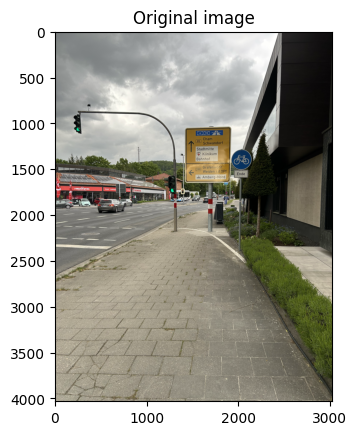

In [50]:
img_bgr = cv2.imread(IMAGE_PATH)

# bgr zu rgb 
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


plt.imshow(img_rgb)
#plt.axis('off')
plt.title('Original image')
plt.show()

---
Professorin Ivanovska nach Erlaubnis gebeten Bilder zu skalieren:  
  
Nicht besprocehn, aber weil die Bidler os groß sind sollte man diese auf ein einheitliches kleineres Bildforamt packen, damit alle Funktionen mit den entsprechenden Variablen gleichermaßen funktionieren und manceh Funktionen nicht mehr zu lange dauern


---

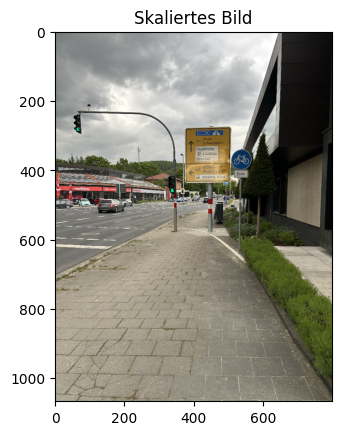

In [51]:
# Bilder skalieren
img_rgb.shape[1]
img_width = 800
scale =img_width / img_rgb.shape[1]

skaliertes_img = cv2.resize(img_rgb, (0, 0), fx=scale, fy=scale)

plt.imshow(skaliertes_img)
plt.title('Skaliertes Bild')
plt.show()

In [52]:
img_rgb = skaliertes_img

#### Bilateral Filter (Vorlesung 4 Folie 14–25)

Kanten bleiben erhalten. Sinnvoll für Schilder

let src = cv.imread('canvasInput');  
let dst = new cv.Mat();  
cv.cvtColor(src, src, cv.COLOR_RGBA2RGB, 0);  
// You can try more different parameters  
cv.bilateralFilter(src, dst, 9, 75, 75, cv.BORDER_DEFAULT);  
cv.imshow('canvasOutput', dst);  
src.delete(); dst.delete();  

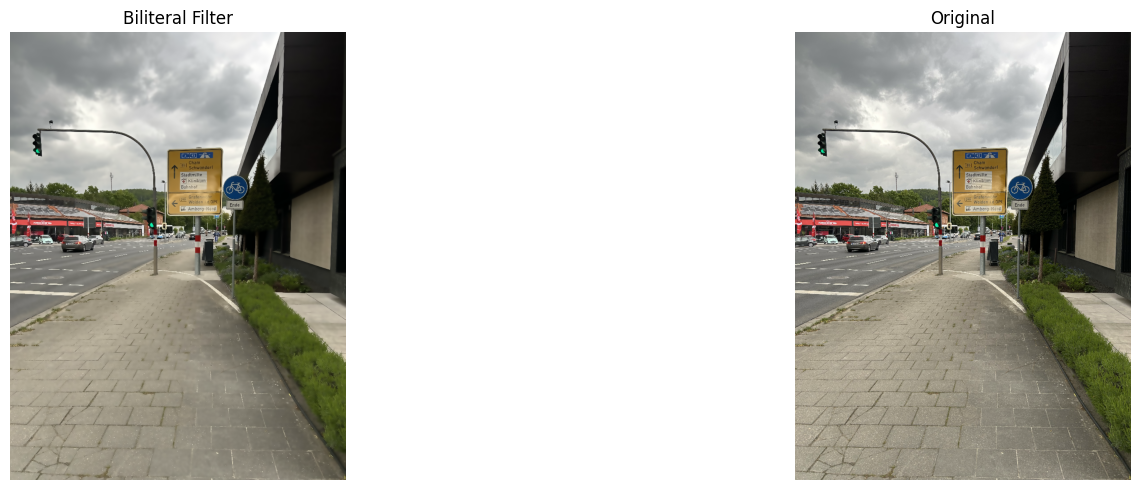

In [53]:
# Biletaral Filter 

img_filtered = cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

axes[0].imshow(img_filtered)
axes[0].set_title("Biliteral Filter")
axes[0].axis('off')

axes[1].imshow(img_rgb)
axes[1].set_title("Original")
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### CLAHE Vorlesung 6

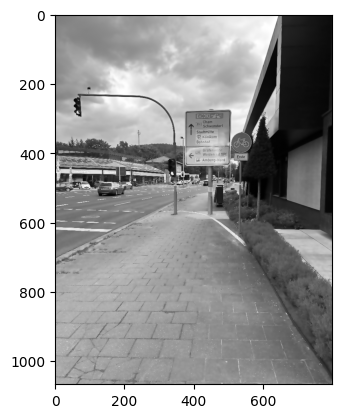

In [54]:
#Vorbvereitung
#rgb zu hsv (HE wird auf V-Kanal angewendet)
image_hsv_raw = cv2.cvtColor(img_filtered, cv2.COLOR_RGB2HSV)
#print(image_hsv_raw.shape)
v_channel = image_hsv_raw[:, :, 2]
#print(v_channel.shape)
plt.imshow(v_channel, cmap='gray')



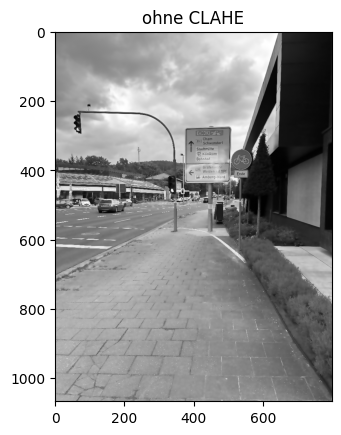

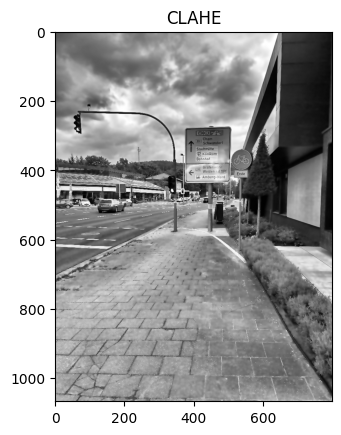

In [55]:
# CLAHE erstellen und auf v-kanal
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
v_clahe = clahe.apply(v_channel)


plt.imshow(v_channel, cmap='gray')
plt.title("ohne CLAHE")
plt.show()

plt.imshow(v_clahe, cmap='gray')
plt.title("CLAHE")
plt.show()

---

In [56]:
# rgb zu hsv
img_hsv = cv2.cvtColor(img_filtered, cv2.COLOR_RGB2HSV)

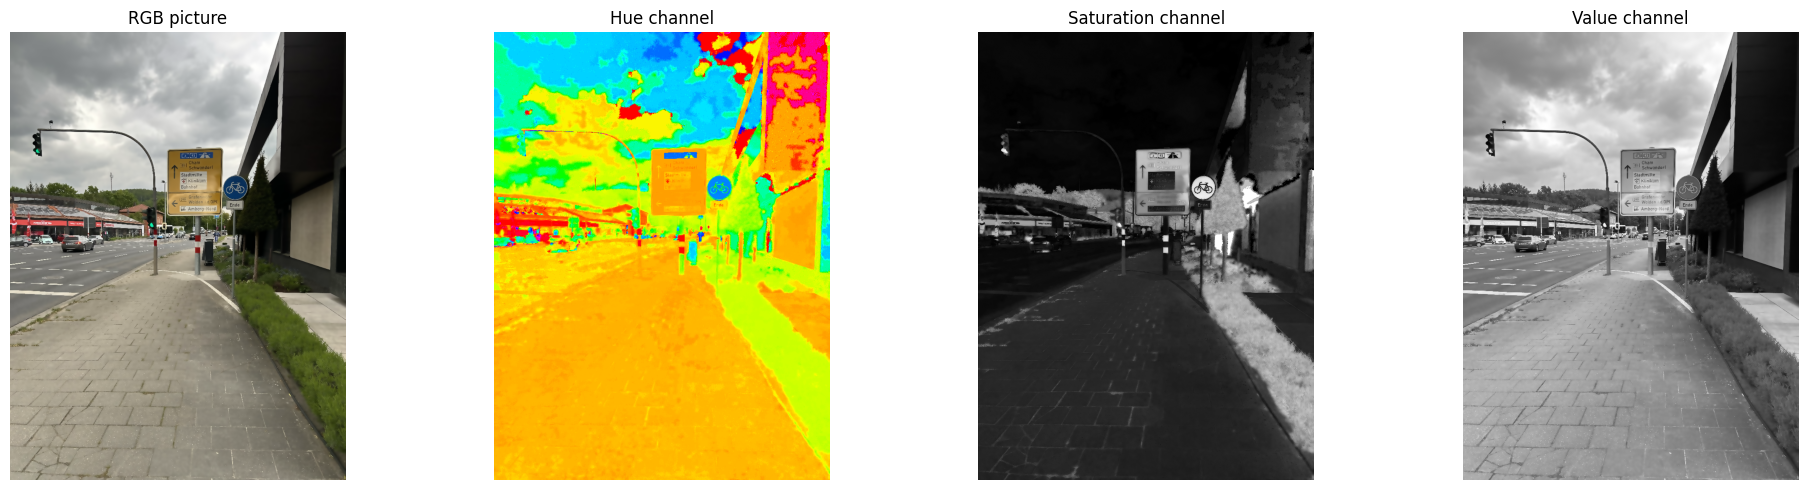

In [57]:
# hsv in die Kanäle untertielen 
h_channel = img_hsv[:, :, 0]
s_channel = img_hsv[:, :, 1]
v_channel = img_hsv[:, :, 2]

#Kanäle anzeigen lassen
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_filtered)
axes[0].set_title("RGB picture")
axes[0].axis('off')

axes[1].imshow(h_channel, cmap='hsv')
axes[1].set_title("Hue channel")
axes[1].axis('off')

axes[2].imshow(s_channel, cmap='gray')
axes[2].set_title("Saturation channel")
axes[2].axis('off')

axes[3].imshow(v_channel, cmap='gray')
axes[3].set_title("Value channel")
axes[3].axis('off')

plt.tight_layout()
plt.show()

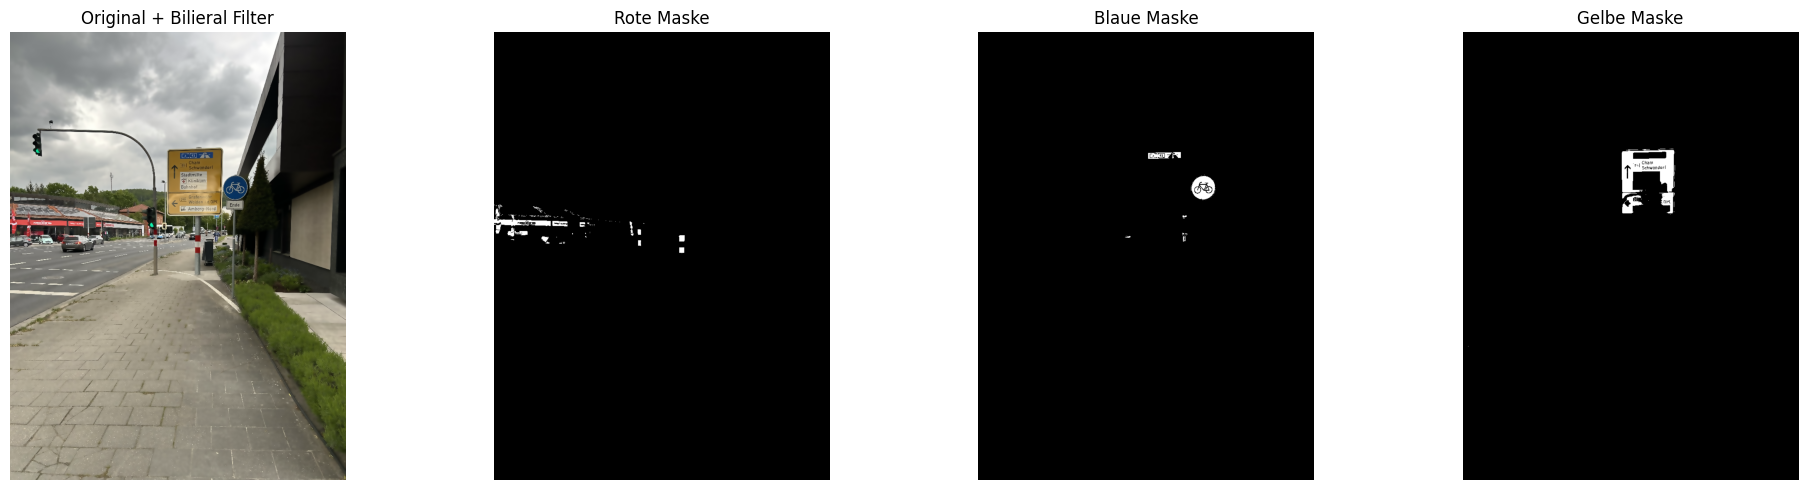

In [58]:
# Maske/ Farbräume für das HSV Treshholding
masks = {
    "rot":   cv2.inRange(img_hsv,   np.array([0, 125, 50]), np.array([10, 255, 250])) 
           | cv2.inRange(img_hsv,   np.array([170, 125, 50]), np.array([179, 255, 250])),
    "blau": cv2.inRange(img_hsv, np.array([90, 80, 50]),  np.array([120, 255, 255])),
    "gelb": cv2.inRange(img_hsv, np.array([18, 130, 100]),  np.array([27, 220, 200])),

}


# Die 3 Masken anzeigen lassen
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_filtered)
axes[0].set_title("Original + Bilieral Filter")
axes[0].axis('off')

axes[1].imshow(masks["rot"], cmap='gray')
axes[1].set_title("Rote Maske")
axes[1].axis('off')

axes[2].imshow(masks["blau"], cmap='gray')
axes[2].set_title("Blaue Maske")
axes[2].axis('off')

axes[3].imshow(masks["gelb"], cmap='gray')
axes[3].set_title("Gelbe Maske")
axes[3].axis('off')



plt.tight_layout()
plt.show()

Mathematische Morphologie  
Vorlesung 5  
Seite 11  
  
import cv2  
import numpy as np  
  
img = cv2.imread('j.png',0)  
kernel = np.ones((5,5),np.uint8)  
erosion = cv2.erode(img, kernel, iterations = 1)  

  
##### Rectangular Kernel  
 cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))  
array([[1, 1, 1, 1, 1],  
[1, 1, 1, 1, 1],  
[1, 1, 1, 1, 1],  
[1, 1, 1, 1, 1],  
[1, 1, 1, 1, 1]], dtype=uint8)  
  
##### Elliptical Kernel  
 cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))  
array([[0, 0, 1, 0, 0],  
[1, 1, 1, 1, 1],  
[1, 1, 1, 1, 1],  
[1, 1, 1, 1, 1],  
[0, 0, 1, 0, 0]], dtype=uint8)  
  
##### Cross-shaped Kernel  
 cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))  
array([[0, 0, 1, 0, 0],  
[0, 0,1, 0, 0],  
[1, 1, 1, 1, 1],  
[0, 0,1, 0,0],  
[0, 0, 1, 0, 0]], dtype=uint8)  

Seite 28  
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)  
  
Seite 29  
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)  

In [59]:
kernel_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4, 4))
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

mask_rot_clean  = cv2.morphologyEx(masks["rot"],  cv2.MORPH_OPEN,  kernel_open,  iterations=1)
mask_rot_clean  = cv2.morphologyEx(mask_rot_clean, cv2.MORPH_CLOSE, kernel_close, iterations=2)

mask_blau_clean = cv2.morphologyEx(masks["blau"], cv2.MORPH_OPEN,  kernel_open,  iterations=1)
mask_blau_clean = cv2.morphologyEx(mask_blau_clean, cv2.MORPH_CLOSE, kernel_close, iterations=2)

mask_gelb_clean = cv2.morphologyEx(masks["gelb"], cv2.MORPH_OPEN,  kernel_open,  iterations=1)
mask_gelb_clean = cv2.morphologyEx(mask_gelb_clean, cv2.MORPH_CLOSE, kernel_close, iterations=2)

clean_masks = {
    "rot": mask_rot_clean,
    "blau": mask_blau_clean,
    "gelb": mask_gelb_clean
}

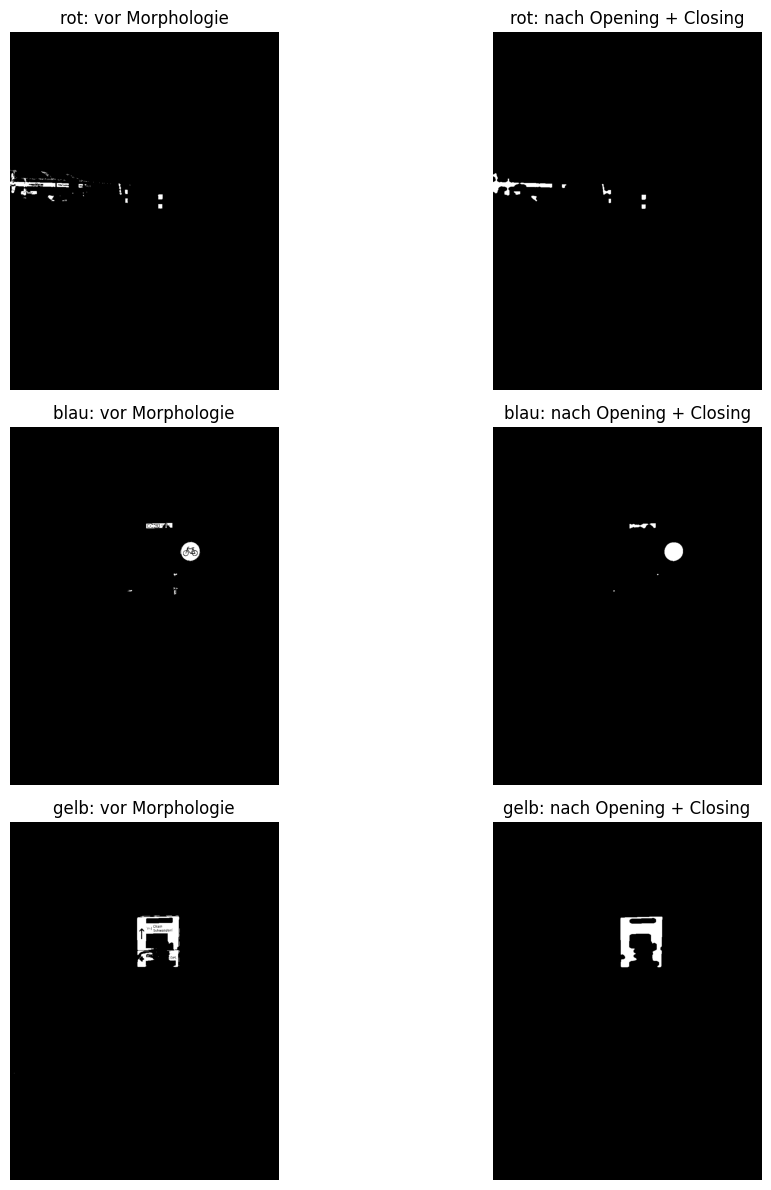

In [60]:
# Vorher und nacheher vergleichen
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 12))

ax1.imshow(masks["rot"], cmap='gray')
ax1.set_title("rot: vor Morphologie")
ax1.axis('off')

ax2.imshow(mask_rot_clean, cmap='gray')
ax2.set_title("rot: nach Opening + Closing")
ax2.axis('off')

ax3.imshow(masks["blau"], cmap='gray')
ax3.set_title("blau: vor Morphologie")
ax3.axis('off')

ax4.imshow(mask_blau_clean, cmap='gray')
ax4.set_title("blau: nach Opening + Closing")
ax4.axis('off')

ax5.imshow(masks["gelb"], cmap='gray')
ax5.set_title("gelb: vor Morphologie")
ax5.axis('off')

ax6.imshow(mask_gelb_clean, cmap='gray')
ax6.set_title("gelb: nach Opening + Closing")
ax6.axis('off')

plt.tight_layout()
plt.show()


Vorlesung 2 Seite 49
  
import cv2  
from skimage import img_as_ubyte  
cv_blobs = img_as_ubyte(blobs)  
num_labels, labels_im = cv2.connectedComponents(cv_blobs)  
print("Opencv components:", num_labels)  
plt.imshow(labels_im, cmap='gray')  

In [61]:
MIN_AREA = 600

Minimal größer von Komonenten verlangen um kleien übrig gebliebene fetzen nicht zu segmentieren  
Aspect Ratio nutzten, um Rechtecke die keine Schilder sein können, nicht segmentiert werden

In [62]:
def find_signs(mask, mask_color, connectivity=8):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    sings = []

    for label_id in range(1, num_labels):
        x = stats[label_id, cv2.CC_STAT_LEFT]
        y = stats[label_id, cv2.CC_STAT_TOP]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]
        area = stats[label_id, cv2.CC_STAT_AREA]
        cx, cy = centroids[label_id]
        aspect_ratio = w / h

        if area < MIN_AREA or not (0.5 <= aspect_ratio <= 2.0):
            continue
        
        #Convex Hull (Vorlesung 5, Folie 53)
        region_mask = (labels == label_id).astype(np.uint8)
        contours, _ = cv2.findContours(region_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        hull = cv2.convexHull(contours[0])
        hull_area = cv2.contourArea(hull)
        if hull_area > 0:
            hull_ratio = area / hull_area
        else:
            hull_ratio = 0.0

        sings.append(
            {"color": mask_color,
            "bbox": (x, y, w, h), 
            "area": area, 
            "centroid": (cx, cy), 
            "aspect_ratio": aspect_ratio,
            "hull_ratio": hull_ratio,}
            )
    return sings


In [63]:
# Alle Schilder in den 3 Masken finden
found_signs = []

for color, mask in clean_masks.items():
    signs = find_signs(mask, color)
    found_signs += signs

In [64]:
print("Found signs:", len(found_signs))
for sign in found_signs:
    print(sign)

Found signs: 3
{'color': 'rot', 'bbox': (0, 421, 78, 67), 'area': 1739, 'centroid': (28.252443933294998, 456.59114433582516), 'aspect_ratio': 1.164179104477612, 'hull_ratio': 0.5224575634670272}
{'color': 'blau', 'bbox': (510, 344, 55, 56), 'area': 2435, 'centroid': (537.0451745379877, 370.741273100616), 'aspect_ratio': 0.9821428571428571, 'hull_ratio': 1.0190416405105671}
{'color': 'gelb', 'bbox': (379, 282, 125, 151), 'area': 10233, 'centroid': (437.7346819114629, 345.5557510016613), 'aspect_ratio': 0.8278145695364238, 'hull_ratio': 0.5609121056814756}


https://docs.python.org/3/howto/sorting.html  
Array sortieren:  
  
student_tuples = [  
    ('john', 'A', 15),  
    ('jane', 'B', 12),  
    ('dave', 'B', 10),  
]  
sorted(student_tuples, key=lambda student: student[2])   # sort by age  
[('dave', 'B', 10), ('jane', 'B', 12), ('john', 'A', 15)]  

In [65]:
# Entferne kleiner Bounding Boxes die in einer großen Liegen
found_signs = sorted(found_signs, key=lambda sign: sign["area"], reverse=True)


filtered_signs = []

for sign in found_signs:
    x_begin, y_begin, w, h = sign["bbox"]
    x_end, y_end = x_begin + w, y_begin + h
    
    is_inside_bigger = False  
    
    for bigger in filtered_signs:
        x_box_begin, y_box_begin, w_box, h_box = bigger["bbox"]
        x_box_end, y_box_end = x_box_begin + w_box, y_box_begin + h_box
        
        if (x_begin >= x_box_begin and x_end <= x_box_end and 
            y_begin >= y_box_begin and y_end <= y_box_end):
            is_inside_bigger = True
            break
    
    if not is_inside_bigger:
        filtered_signs.append(sign)
        
found_signs = filtered_signs

print("Nach entfernen von überflüssigen Bounding Boxen:", len(found_signs), "Schilder")
for sign in found_signs:
    print(sign)

Nach entfernen von überflüssigen Bounding Boxen: 3 Schilder
{'color': 'gelb', 'bbox': (379, 282, 125, 151), 'area': 10233, 'centroid': (437.7346819114629, 345.5557510016613), 'aspect_ratio': 0.8278145695364238, 'hull_ratio': 0.5609121056814756}
{'color': 'blau', 'bbox': (510, 344, 55, 56), 'area': 2435, 'centroid': (537.0451745379877, 370.741273100616), 'aspect_ratio': 0.9821428571428571, 'hull_ratio': 1.0190416405105671}
{'color': 'rot', 'bbox': (0, 421, 78, 67), 'area': 1739, 'centroid': (28.252443933294998, 456.59114433582516), 'aspect_ratio': 1.164179104477612, 'hull_ratio': 0.5224575634670272}


In [66]:
#Klassifikation der Schilder anhand Form und Farbe

def classify_sign(color, area, w, h, cx, cy, x, y, hull_ratio):
    fill_ratio = area / (w * h)            # Fläche / Bbox Fläche
    aspect_ratio = w / h
    is_squarish = 0.75 <= aspect_ratio <= 1.25
    '''
    if hull_ratio < 0.70:
        return "Unbekannt"
    '''
    cy_rel = (cy - y) / h

    # Rote Schilder
    if color == "rot":
        if not is_squarish:
            return "Unbekannt"
        if fill_ratio > 0.30:
            return "Verbotsschild"   
        if cy_rel > 0.55:
            return "Gefahrenschild"
        if cy_rel < 0.45:
            return "Vorfahrt gewaehren"
        return "Unbekannt"
    
    # Blaue Schilder
    if color == "blau":
        if is_squarish:
            return "Gebotsschild"              
        return "Hinweisschild"                 
    
     # Gelbe Schilder
    if color == "gelb":
        if 0.85 <= aspect_ratio <= 1.20:
            return "Vorfahrtsstrasse"
        if aspect_ratio < 0.85:
            return "Ortsschild / Wegweiser"
        return "Unbekannt"


    return "Unbekannt"

In [67]:
# Klassifikation der gefundenen Schilder
for sign in found_signs:
    x, y, w, h = sign["bbox"]
    cx, cy = sign["centroid"]

    sign["klasse"] = classify_sign(
        sign["color"], 
        sign["area"], 
        w, h, cx, cy, x, y,
        sign["hull_ratio"]
    )

print("Klassifizierte Schilder:", len(found_signs))
for sign in found_signs:
    print(sign)

Klassifizierte Schilder: 3
{'color': 'gelb', 'bbox': (379, 282, 125, 151), 'area': 10233, 'centroid': (437.7346819114629, 345.5557510016613), 'aspect_ratio': 0.8278145695364238, 'hull_ratio': 0.5609121056814756, 'klasse': 'Ortsschild / Wegweiser'}
{'color': 'blau', 'bbox': (510, 344, 55, 56), 'area': 2435, 'centroid': (537.0451745379877, 370.741273100616), 'aspect_ratio': 0.9821428571428571, 'hull_ratio': 1.0190416405105671, 'klasse': 'Gebotsschild'}
{'color': 'rot', 'bbox': (0, 421, 78, 67), 'area': 1739, 'centroid': (28.252443933294998, 456.59114433582516), 'aspect_ratio': 1.164179104477612, 'hull_ratio': 0.5224575634670272, 'klasse': 'Verbotsschild'}


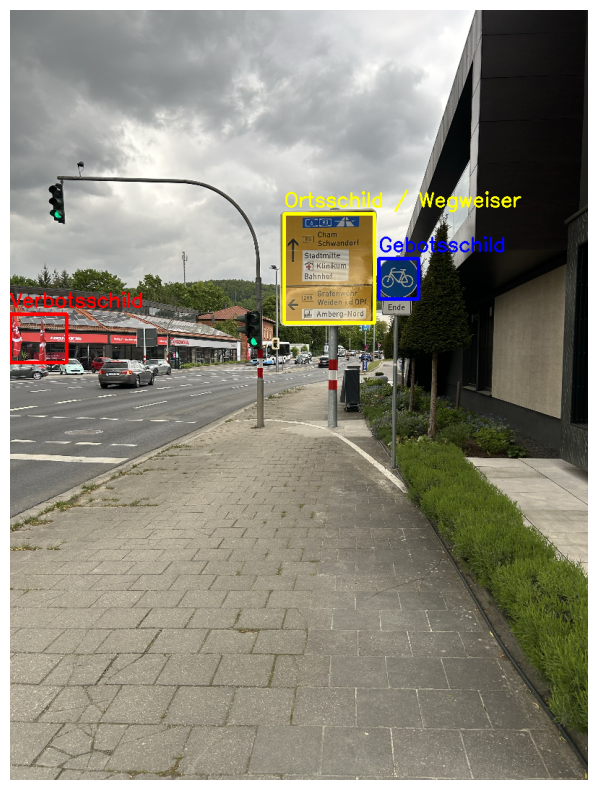

In [68]:
# Farben für die Bounding Boxes
color_map = {
    "rot":  (255, 0, 0),
    "blau": (0, 0, 255),
    "gelb": (255, 255, 0),
}

# Kopie
img_result = img_rgb.copy()

for sign in found_signs:
    x, y, w, h = sign["bbox"]
    color = color_map[sign["color"]]
    #BBox und Klasse zeichnen
    cv2.rectangle(img_result, (x, y), (x + w, y + h), color, 4)

    label = sign["klasse"]
    cv2.putText(img_result, label, (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    
# Ergebnis anzeigen
plt.figure(figsize=(14, 10))
plt.imshow(img_result)
plt.axis('off')
plt.show()